In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
import warnings
warnings.filterwarnings("ignore")

In [6]:
DATA_ROOT = r"E:\third semester\second term\AML\project\face-mask-detection\data"
SPLITS    = ["train", "val", "test"]
CLASSES   = ["WithMask", "WithoutMask"]
COLORS    = {"WithMask": "#2ecc71", "WithoutMask": "#e74c3c"}
 
random.seed(42)
np.random.seed(42)

## collect data 

In [ ]:
def collect_paths():
    data = {}
    for split in SPLITS:
        data[split] = {}
        for cls in CLASSES:
            folder = os.path.join(DATA_ROOT, split, cls)
            imgs = [os.path.join(folder, f)
                    for f in os.listdir(folder)
                    if f.lower().endswith((".png", ".jpg", ".jpeg"))]
            data[split][cls] = imgs
    return data
 
data = collect_paths()
 
counts = {split: {cls: len(data[split][cls]) for cls in CLASSES} for split in SPLITS}
print("=== Dataset Counts ===")
for split in SPLITS:
    for cls in CLASSES:
        print(f"  {split:6s} | {cls:15s} : {counts[split][cls]:,}")

=== Dataset Counts ===
  train  | WithMask        : 5,000
  train  | WithoutMask     : 5,000
  val    | WithMask        : 400
  val    | WithoutMask     : 400
  test   | WithMask        : 483
  test   | WithoutMask     : 509


## meta data

In [ ]:
def get_meta(paths, max_samples=500):
    """
    بتاخد sample من الصور وبترجع:
      widths, heights, file_sizes, brightness_vals, r_means, g_means, b_means
    """
    sample = random.sample(paths, min(max_samples, len(paths)))
    widths, heights, fsizes, brightness, r_m, g_m, b_m = [], [], [], [], [], [], []
 
    for p in sample:
        try:
            img = Image.open(p).convert("RGB")
            w, h = img.size
            arr = np.array(img, dtype=np.float32)
            widths.append(w)
            heights.append(h)
            fsizes.append(os.path.getsize(p) / 1024)   # KB
            brightness.append(arr.mean())
            r_m.append(arr[:,:,0].mean())
            g_m.append(arr[:,:,1].mean())
            b_m.append(arr[:,:,2].mean())
        except Exception:
            pass
 
    return dict(widths=widths, heights=heights, fsizes=fsizes,
                brightness=brightness, r=r_m, g=g_m, b=b_m)
 
meta = {}
for cls in CLASSES:
    all_paths = []
    for split in SPLITS:
        all_paths.extend(data[split][cls])
    meta[cls] = get_meta(all_paths, max_samples=600)

## plots

<Figure size 2200x3000 with 0 Axes>

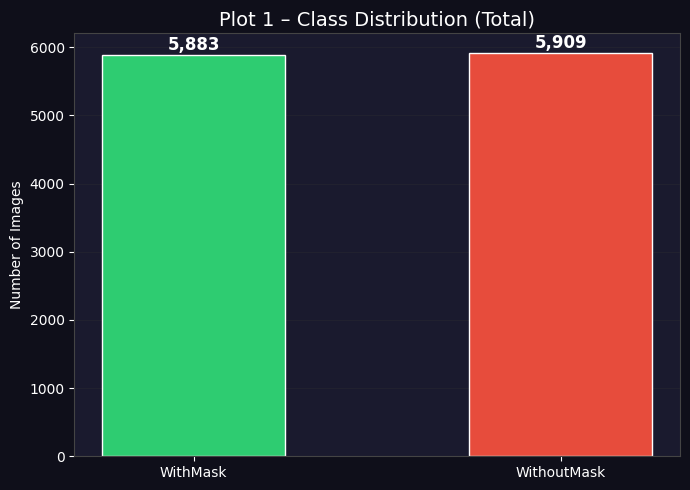

In [22]:
def plot1_class_distribution():
    total = {cls: sum(counts[s][cls] for s in SPLITS) for cls in CLASSES}
    fig, ax = plt.subplots(figsize=(7, 5))
    bars = ax.bar(CLASSES, [total[c] for c in CLASSES],
                  color=[COLORS[c] for c in CLASSES],
                  edgecolor="white", width=0.5)
    for bar, val in zip(bars, total.values()):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 80,
                f"{val:,}", ha="center", fontsize=12, fontweight="bold")
    ax.set_title("Plot 1 – Class Distribution (Total)", fontsize=14)
    ax.set_ylabel("Number of Images")
    ax.yaxis.grid(True, alpha=0.3); ax.set_axisbelow(True)
    plt.tight_layout(); plt.show()
plot1_class_distribution()    

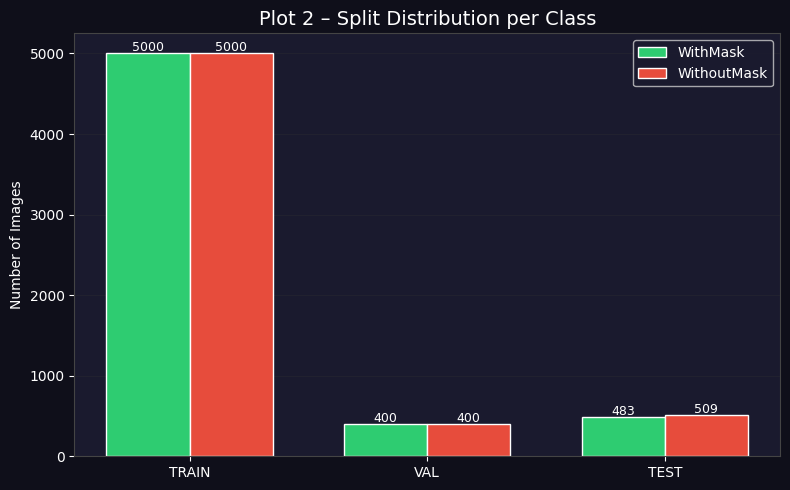

In [23]:
def plot2_split_distribution():
    x, w = np.arange(len(SPLITS)), 0.35
    fig, ax = plt.subplots(figsize=(8, 5))
    for i, cls in enumerate(CLASSES):
        vals  = [counts[s][cls] for s in SPLITS]
        rects = ax.bar(x + i*w - w/2, vals, w,
                       label=cls, color=COLORS[cls], edgecolor="white")
        for rect, v in zip(rects, vals):
            ax.text(rect.get_x() + rect.get_width()/2,
                    rect.get_height() + 30,
                    str(v), ha="center", fontsize=9)
    ax.set_xticks(x); ax.set_xticklabels([s.upper() for s in SPLITS])
    ax.set_title("Plot 2 – Split Distribution per Class", fontsize=14)
    ax.set_ylabel("Number of Images")
    ax.legend(); ax.yaxis.grid(True, alpha=0.3); ax.set_axisbelow(True)
    plt.tight_layout(); plt.show()
plot2_split_distribution()    

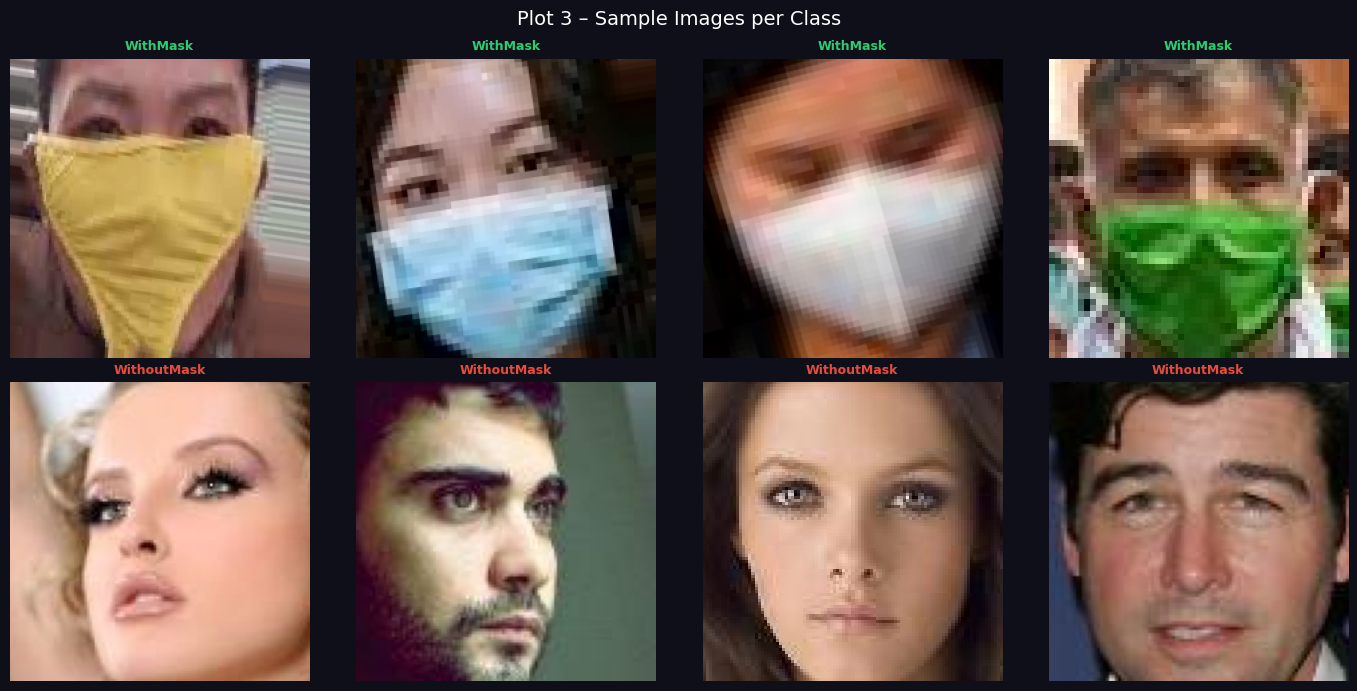

In [14]:
def plot3_sample_images():
    fig, axes = plt.subplots(2, 4, figsize=(14, 7))
    for row, cls in enumerate(CLASSES):
        samples = random.sample(data["train"][cls], 4)
        for col, path in enumerate(samples):
            img = Image.open(path).convert("RGB")
            axes[row][col].imshow(img)
            axes[row][col].axis("off")
            axes[row][col].set_title(cls, fontsize=9,
                                     color=COLORS[cls], fontweight="bold")
    fig.suptitle("Plot 3 – Sample Images per Class", fontsize=14)
    plt.tight_layout(); plt.show()
plot3_sample_images()    

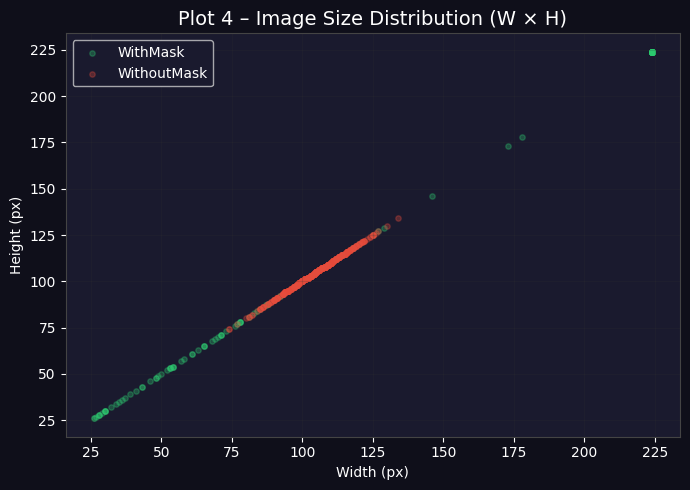

In [24]:
def plot4_image_sizes():
    fig, ax = plt.subplots(figsize=(7, 5))
    for cls in CLASSES:
        ax.scatter(meta[cls]["widths"], meta[cls]["heights"],
                   alpha=0.3, s=15, color=COLORS[cls], label=cls)
    ax.set_xlabel("Width (px)"); ax.set_ylabel("Height (px)")
    ax.set_title("Plot 4 – Image Size Distribution (W × H)", fontsize=14)
    ax.legend(); ax.grid(True, alpha=0.2)
    plt.tight_layout(); plt.show()
plot4_image_sizes()


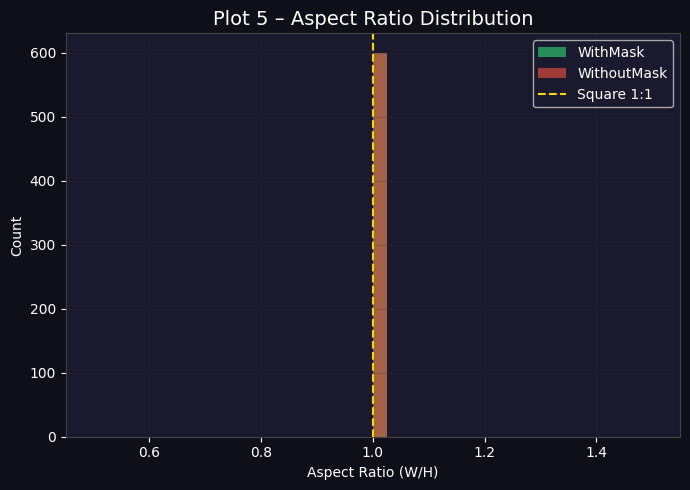

In [25]:
def plot5_aspect_ratio():
    fig, ax = plt.subplots(figsize=(7, 5))
    for cls in CLASSES:
        ratios = np.array(meta[cls]["widths"]) / np.array(meta[cls]["heights"])
        ax.hist(ratios, bins=40, alpha=0.65, color=COLORS[cls], label=cls)
    ax.axvline(1.0, color="gold", linestyle="--", label="Square 1:1")
    ax.set_xlabel("Aspect Ratio (W/H)"); ax.set_ylabel("Count")
    ax.set_title("Plot 5 – Aspect Ratio Distribution", fontsize=14)
    ax.legend(); ax.grid(True, alpha=0.2)
    plt.tight_layout(); plt.show()
plot5_aspect_ratio()

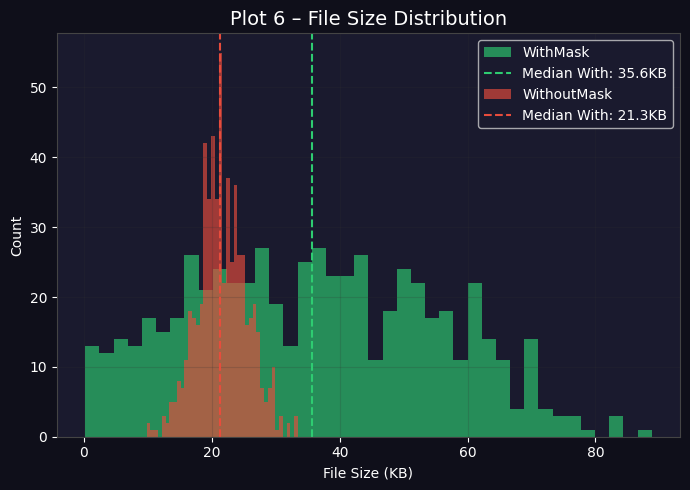

In [26]:
def plot6_file_size():
    fig, ax = plt.subplots(figsize=(7, 5))
    for cls in CLASSES:
        ax.hist(meta[cls]["fsizes"], bins=40, alpha=0.65,
                color=COLORS[cls], label=cls)
        med = np.median(meta[cls]["fsizes"])
        ax.axvline(med, color=COLORS[cls], linestyle="--",
                   linewidth=1.5, label=f"Median {cls[:4]}: {med:.1f}KB")
    ax.set_xlabel("File Size (KB)"); ax.set_ylabel("Count")
    ax.set_title("Plot 6 – File Size Distribution", fontsize=14)
    ax.legend(); ax.grid(True, alpha=0.2)
    plt.tight_layout(); plt.show()
plot6_file_size()

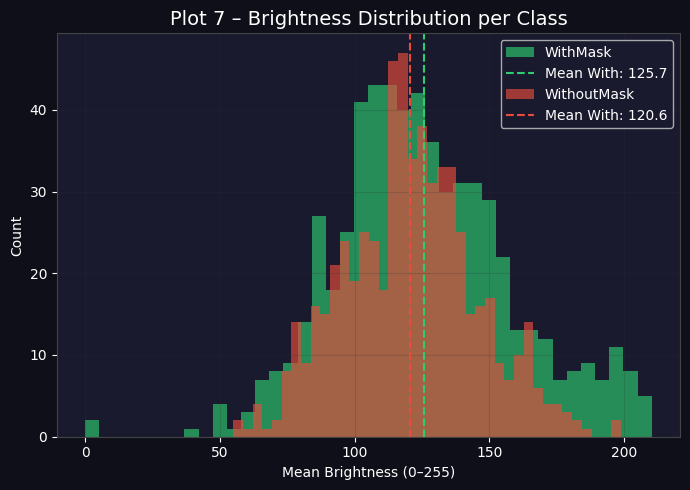

In [27]:
def plot7_brightness():
    fig, ax = plt.subplots(figsize=(7, 5))
    for cls in CLASSES:
        ax.hist(meta[cls]["brightness"], bins=40, alpha=0.65,
                color=COLORS[cls], label=cls)
        mean_b = np.mean(meta[cls]["brightness"])
        ax.axvline(mean_b, color=COLORS[cls], linestyle="--",
                   linewidth=1.5, label=f"Mean {cls[:4]}: {mean_b:.1f}")
    ax.set_xlabel("Mean Brightness (0–255)"); ax.set_ylabel("Count")
    ax.set_title("Plot 7 – Brightness Distribution per Class", fontsize=14)
    ax.legend(); ax.grid(True, alpha=0.2)
    plt.tight_layout(); plt.show()
plot7_brightness()

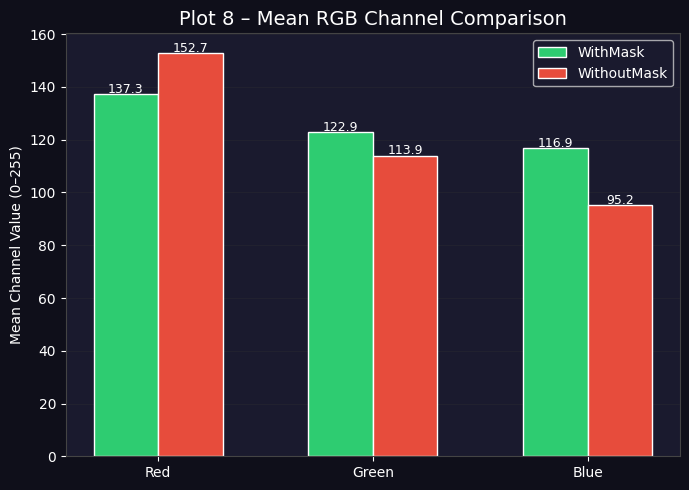

In [28]:
def plot8_rgb_channels():
    channels, chan_keys = ["Red", "Green", "Blue"], ["r", "g", "b"]
    x, w = np.arange(3), 0.3
    fig, ax = plt.subplots(figsize=(7, 5))
    for i, cls in enumerate(CLASSES):
        means = [np.mean(meta[cls][k]) for k in chan_keys]
        bars  = ax.bar(x + i*w - w/2, means, w,
                       label=cls, color=COLORS[cls], edgecolor="white")
        for rect, v in zip(bars, means):
            ax.text(rect.get_x() + rect.get_width()/2,
                    rect.get_height() + 0.5,
                    f"{v:.1f}", ha="center", fontsize=9)
    ax.set_xticks(x); ax.set_xticklabels(channels)
    ax.set_ylabel("Mean Channel Value (0–255)")
    ax.set_title("Plot 8 – Mean RGB Channel Comparison", fontsize=14)
    ax.legend(); ax.yaxis.grid(True, alpha=0.3); ax.set_axisbelow(True)
    plt.tight_layout(); plt.show()
plot8_rgb_channels()

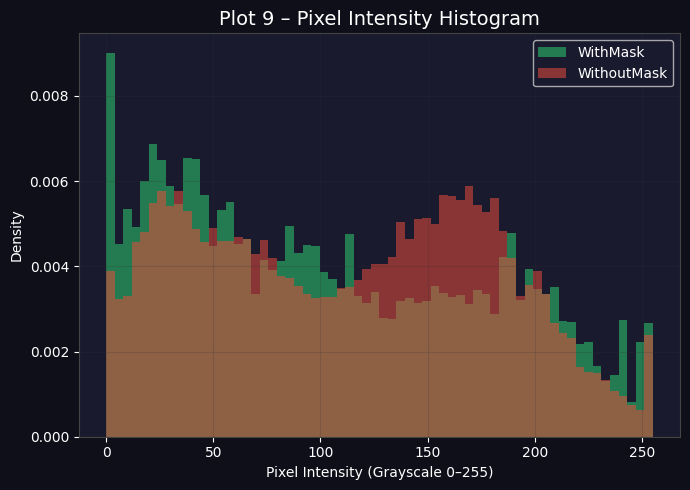

In [29]:
def plot9_pixel_intensity():
    def get_pixels(paths, n=150):
        pixels = []
        for p in random.sample(paths, min(n, len(paths))):
            try:
                arr = np.array(Image.open(p).convert("L"), dtype=np.float32)
                pixels.extend(arr.flatten()[:500].tolist())
            except: pass
        return np.array(pixels)

    fig, ax = plt.subplots(figsize=(7, 5))
    for cls in CLASSES:
        all_paths = [p for s in SPLITS for p in data[s][cls]]
        pix = get_pixels(all_paths)
        ax.hist(pix, bins=64, alpha=0.55, color=COLORS[cls],
                label=cls, density=True)
    ax.set_xlabel("Pixel Intensity (Grayscale 0–255)")
    ax.set_ylabel("Density")
    ax.set_title("Plot 9 – Pixel Intensity Histogram", fontsize=14)
    ax.legend(); ax.grid(True, alpha=0.2)
    plt.tight_layout(); plt.show()
plot9_pixel_intensity()

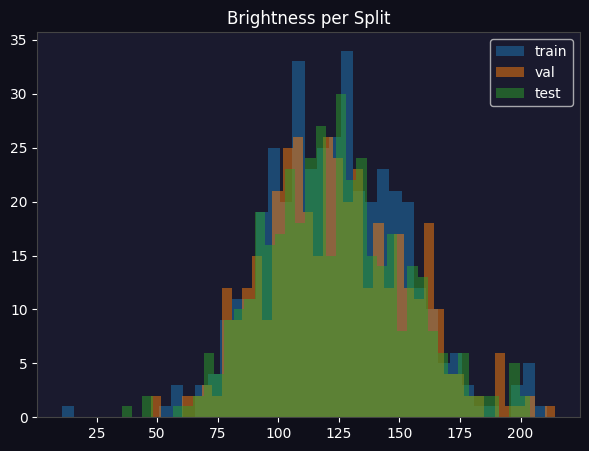

In [30]:
def plot10_brightness_per_split():
    fig, ax = plt.subplots(figsize=(7,5))
    
    for split in SPLITS:
        vals = []
        for cls in CLASSES:
            paths = data[split][cls]
            m = get_meta(paths, max_samples=200)
            vals.extend(m["brightness"])
        ax.hist(vals, bins=40, alpha=0.5, label=split)
    
    ax.set_title("Brightness per Split")
    ax.legend()
    plt.show()
plot10_brightness_per_split()    

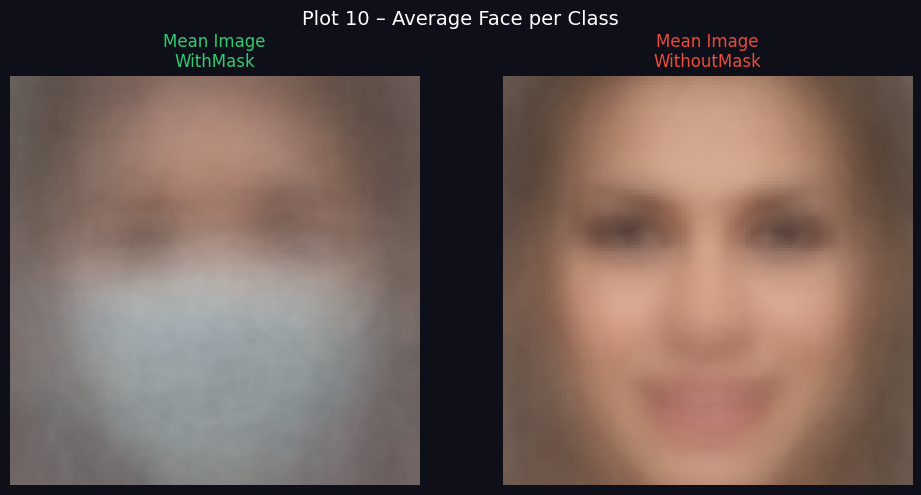

In [31]:
def plot10_mean_image():
    def compute_mean_image(paths, size=(128,128), max_samples=200):
        imgs = []
        for p in random.sample(paths, min(max_samples, len(paths))):
            try:
                img = Image.open(p).convert("RGB").resize(size)
                imgs.append(np.array(img, dtype=np.float32))
            except:
                pass
        if len(imgs) == 0:
            return None
        mean_img = np.mean(imgs, axis=0) / 255.0
        return mean_img

    fig, axes = plt.subplots(1, len(CLASSES), figsize=(10,5))

    for i, cls in enumerate(CLASSES):
        all_paths = [p for s in SPLITS for p in data[s][cls]]
        mean_img = compute_mean_image(all_paths)

        if mean_img is not None:
            axes[i].imshow(mean_img)
            axes[i].set_title(f"Mean Image\n{cls}", color=COLORS[cls])
        axes[i].axis("off")

    plt.suptitle("Plot 10 – Average Face per Class", fontsize=14)
    plt.tight_layout()
    plt.show()
plot10_mean_image()

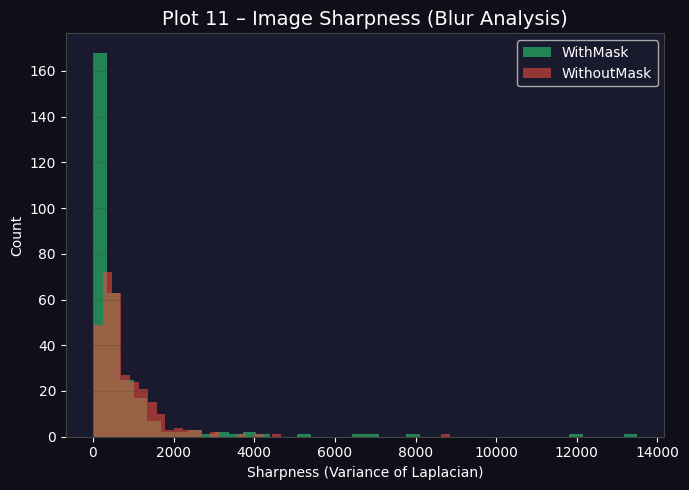

In [34]:
import cv2

def plot11_sharpness():
    def get_sharpness(paths, max_samples=300):
        sharpness = []
        for p in random.sample(paths, min(max_samples, len(paths))):
            try:
                img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
                val = cv2.Laplacian(img, cv2.CV_64F).var()
                sharpness.append(val)
            except:
                pass
        return sharpness

    fig, ax = plt.subplots(figsize=(7,5))

    for cls in CLASSES:
        all_paths = [p for s in SPLITS for p in data[s][cls]]
        sharp_vals = get_sharpness(all_paths)

        ax.hist(sharp_vals, bins=40, alpha=0.6,
                label=cls, color=COLORS[cls])

    ax.set_title("Plot 11 – Image Sharpness (Blur Analysis)", fontsize=14)
    ax.set_xlabel("Sharpness (Variance of Laplacian)")
    ax.set_ylabel("Count")
    ax.legend()
    ax.grid(True, alpha=0.2)

    plt.tight_layout()
    plt.show()
plot11_sharpness()

## Augmentation 

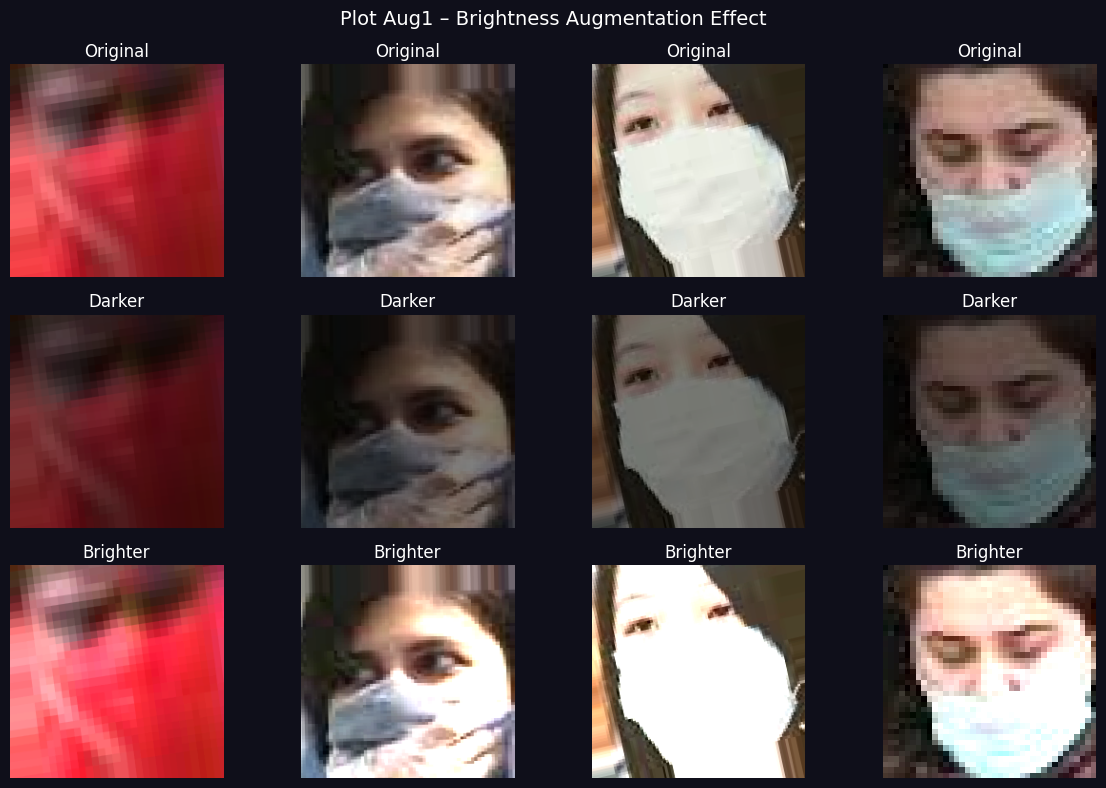

In [35]:
def plot_aug1_brightness_effect():
    fig, axes = plt.subplots(3, 4, figsize=(12,8))

    samples = random.sample(data["train"][CLASSES[0]], 4)

    for i, path in enumerate(samples):
        img = Image.open(path).convert("RGB")

        # original
        axes[0][i].imshow(img)
        axes[0][i].set_title("Original")
        
        # darker
        dark = np.clip(np.array(img) * 0.5, 0, 255).astype(np.uint8)
        axes[1][i].imshow(dark)
        axes[1][i].set_title("Darker")
        
        # brighter
        bright = np.clip(np.array(img) * 1.5, 0, 255).astype(np.uint8)
        axes[2][i].imshow(bright)
        axes[2][i].set_title("Brighter")

        for j in range(3):
            axes[j][i].axis("off")

    plt.suptitle("Plot Aug1 – Brightness Augmentation Effect", fontsize=14)
    plt.tight_layout()
    plt.show()
plot_aug1_brightness_effect()

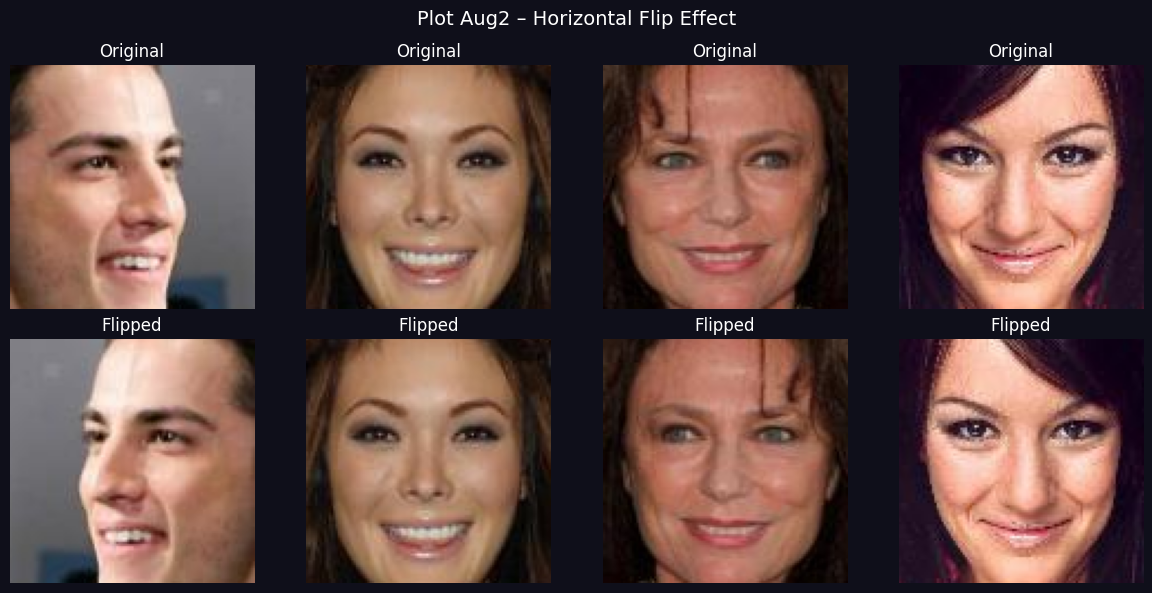

In [36]:
def plot_aug2_flip():
    fig, axes = plt.subplots(2, 4, figsize=(12,6))

    samples = random.sample(data["train"][CLASSES[1]], 4)

    for i, path in enumerate(samples):
        img = Image.open(path).convert("RGB")

        flip = img.transpose(Image.FLIP_LEFT_RIGHT)

        axes[0][i].imshow(img)
        axes[0][i].set_title("Original")

        axes[1][i].imshow(flip)
        axes[1][i].set_title("Flipped")

        axes[0][i].axis("off")
        axes[1][i].axis("off")

    plt.suptitle("Plot Aug2 – Horizontal Flip Effect", fontsize=14)
    plt.tight_layout()
    plt.show()
plot_aug2_flip()

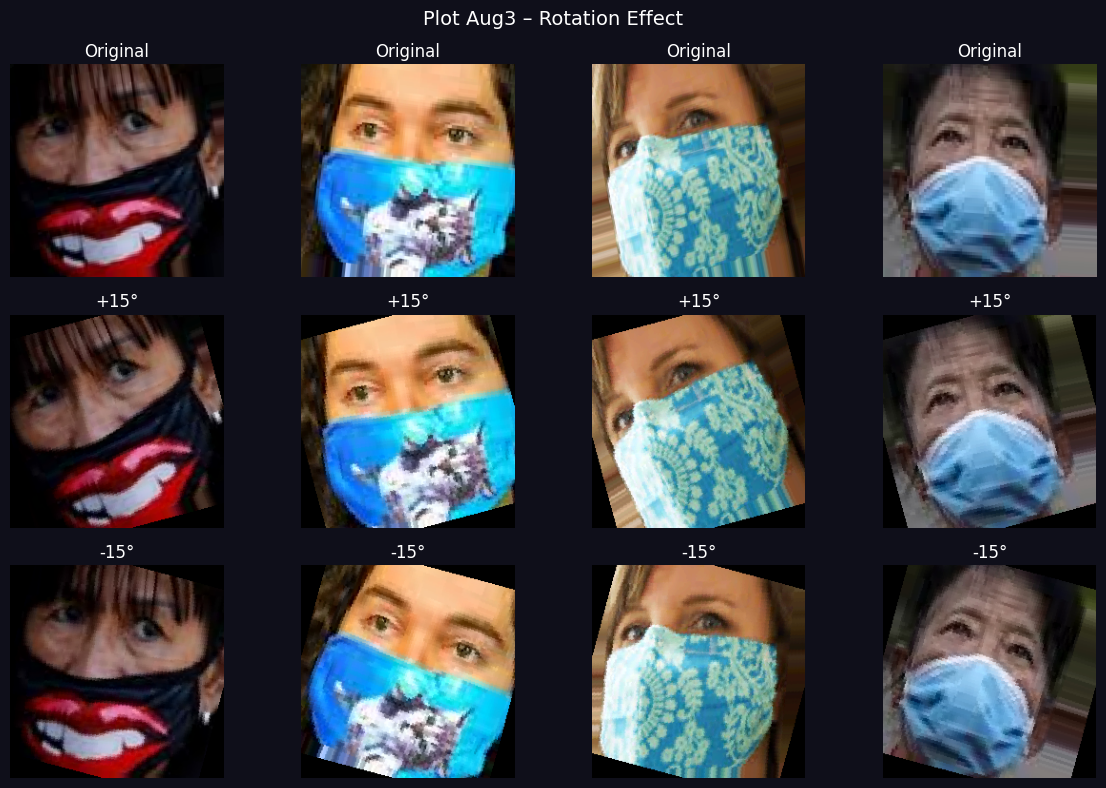

In [37]:
def plot_aug3_rotation():
    fig, axes = plt.subplots(3, 4, figsize=(12,8))

    samples = random.sample(data["train"][CLASSES[0]], 4)

    for i, path in enumerate(samples):
        img = Image.open(path).convert("RGB")

        r1 = img.rotate(15)
        r2 = img.rotate(-15)

        axes[0][i].imshow(img)
        axes[0][i].set_title("Original")

        axes[1][i].imshow(r1)
        axes[1][i].set_title("+15°")

        axes[2][i].imshow(r2)
        axes[2][i].set_title("-15°")

        for j in range(3):
            axes[j][i].axis("off")

    plt.suptitle("Plot Aug3 – Rotation Effect", fontsize=14)
    plt.tight_layout()
    plt.show()
plot_aug3_rotation()

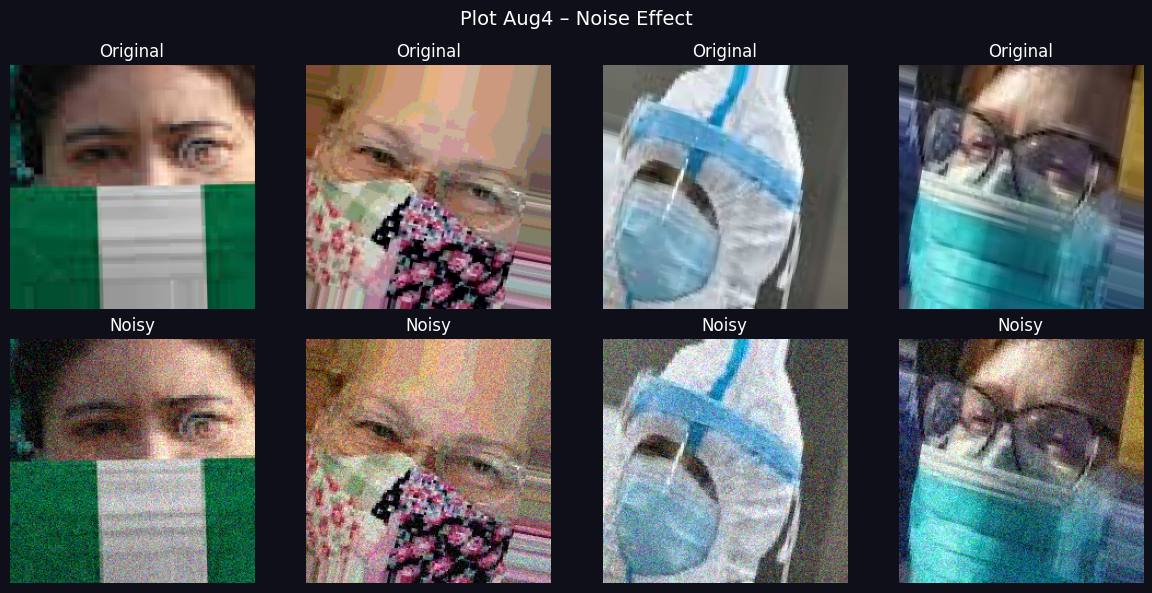

In [38]:
def plot_aug4_noise():
    fig, axes = plt.subplots(2, 4, figsize=(12,6))

    samples = random.sample(data["train"][CLASSES[0]], 4)

    for i, path in enumerate(samples):
        img = Image.open(path).convert("RGB")
        arr = np.array(img)

        noise = np.random.normal(0, 25, arr.shape)
        noisy = np.clip(arr + noise, 0, 255).astype(np.uint8)

        axes[0][i].imshow(img)
        axes[0][i].set_title("Original")

        axes[1][i].imshow(noisy)
        axes[1][i].set_title("Noisy")

        axes[0][i].axis("off")
        axes[1][i].axis("off")

    plt.suptitle("Plot Aug4 – Noise Effect", fontsize=14)
    plt.tight_layout()
    plt.show()
plot_aug4_noise()